# Mobilenet V3 @ CBAM with MFSA
> **CBAM** - Convolutional Block Attention Module.
> 
> Contains:
>  - Channel Attention (Squeeze and Excite Block)
>  - Spatial Attention

> **MFSA** - Multi-Filter Spatial Attention
> - Instead of using single filter as Spatial Attention Score - we use num_filter == num_channel

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import random
import os
import shutil

2025-06-14 13:14:00.163371: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-14 13:14:00.163506: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-14 13:14:00.299247: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Configurations

In [2]:
DEVICE = 'GPU:0' if len(tf.config.list_physical_devices('GPU')) else 'CPU:0'

################################
###### Configurations #########
##############################
seed = 999
SEED = seed
USE_DETERMINISTIC = True
K_FOLD_INDEX = 0
oversampling = 0 # How many times are we gonna over sample

## Model Configurations
MODEL_NAME="T0_MobileNetV3S_CBAM_MFSA-Exp5-KF1.keras"
IMG_SIZE=(224,224,3)
MODEL_TYPE = 'S' ## Mobilenet V3 - 'S' : Small; 'L': Large - default 'S'
FUSION_TYPE = 'add' ## feature fusion [mobilenet output && CBAM output ] - 'average', 'add', 'None' : Concatenate - default 'average'
POOLER_PLACEMENT = None ## Mobilenet Pooler Placement respective to fusion - 'before', 'after', 'None' : Pooler unused - default 'after'
CBAM_ORDER = 'normal' ## Originally in CBAM channel attention precedes spatial attention - 'normal', 'inverted' - default 'normal'
### Apparently CBAM_ORDER do not have much effect on the output --- So no need to use inverted. [check output of Version 2 & 3]

## Training Configurations
BATCH_SIZE=32
EPOCHS = 300
ES_PATIENCE = 13 ## Patience Epoch for Early Stopping
ES_MONITOR = 'val_loss'
LR_REDUCTION_FACTOR = 0.8 ## for ReduceLROnPlateau Callback
LR_REDUCTION_PATIENCE = 3 ## Patience for LR Reduction
LR_REDUCTION_MONITOR = 'val_loss'

##### FineTuning Part
INIT_LR1 = 2e-4 ## Initial Learning Rate (AdamW) 
W_DECAY1 = 5e-2 ## Weight Decay
MIN_LR1 = 1e-6 ## Minimum Learning Rate for ReduceLROnPlateau Callback

USE_WARMUP = False
WARMUP_EPOCH = 10
WARMUP_INIT_LR = INIT_LR1 / WARMUP_EPOCH
WARMUP_MAX_LR = INIT_LR1
WARMUP_INCREMENT_RATE = 0.5
##### Base Model Freezing Part
INIT_LR2 = 2e-5 # Initial Learning Rate for optimizer (AdamW)
W_DECAY2 = 5e-5 ## Weight Decay for optimizer
MIN_LR2 = 1e-9 # Minimum Learning Rate for ReduceLROnPlateau


def seedEverything(seed, deterministic = False):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)

    if deterministic:
        tf.config.experimental.enable_op_determinism()

        os.environ['TF_DETERMINISTIC_OPS'] = '1'
        os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

        tf.config.threading.set_inter_op_parallelism_threads(2)
        tf.config.threading.set_intra_op_parallelism_threads(2)


seedEverything(seed, USE_DETERMINISTIC)
tf.__version__

'2.15.0'

In [3]:
## Downloading DeepWeeds Data  ## For Google Colab
# url = 'https://drive.google.com/uc?export=download&id=1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj'
# !gdown 1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj
# !unzip -qq images.zip -d images

In [4]:
# data_info = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/labels.csv') ## for GoogleColab
data_info = pd.read_csv("/kaggle/input/deepweeds/labels.csv") ## For Kaggle
data_info

,Filename,Label,Species
0,20160928-140314-0.jpg,0,Chinee apple
1,20160928-140337-0.jpg,0,Chinee apple
2,20160928-140731-0.jpg,0,Chinee apple
3,20160928-140747-0.jpg,0,Chinee apple
4,20160928-141107-0.jpg,0,Chinee apple
...,...,...,...
17504,20180322-133822-1.jpg,8,Negative
17505,20180322-133832-1.jpg,8,Negative
17506,20180322-133840-1.jpg,8,Negative
17507,20180322-133850-1.jpg,8,Negative


In [5]:
data_info[['Species','Label']].groupby(by='Species').count().T

Species,Chinee apple,Lantana,Negative,Parkinsonia,Parthenium,Prickly acacia,Rubber vine,Siam weed,Snake weed
Label,1125,1064,9106,1031,1022,1062,1009,1074,1016


In [6]:
label2id = data_info[['Species','Label']].groupby(by='Species').min().to_dict()['Label']
id2label = {label2id[i]:i for i in label2id}
id2label

{0: 'Chinee apple',
 1: 'Lantana',
 8: 'Negative',
 2: 'Parkinsonia',
 3: 'Parthenium',
 4: 'Prickly acacia',
 5: 'Rubber vine',
 6: 'Siam weed',
 7: 'Snake weed'}

In [7]:
low_data_labels = data_info[data_info['Species'] != "Negative"]['Label'].unique() ## labels with very low data
low_data_labels

array([0, 1, 7, 6, 4, 3, 5, 2])

# Splitting Data into Train:Valid:Test Splits (60:20:20)

In [8]:
# colabAI prompt: train test split using data_info
from sklearn.model_selection import train_test_split, StratifiedKFold

### K-Fold Validation-----
#####---------------------
split_index = K_FOLD_INDEX # index to retrieve
print("Using KFold: Index",split_index+1,"out of 5 folds")
print("-------------------------------------------------\n")

# skfold = StratifiedKFold()
# kSplits = skfold.split(data_info['Filename'], y=data_info['Label'])

# for index in range(skfold.get_n_splits()):
#     train_index, test_index = next(kSplits)
#     if index == split_index:
#         break

# trax, tex, tray, tey = train_test_split(data_info['Filename'],data_info['Label'], test_size=0.4, random_state=seed)
# train_data = pd.DataFrame({"Filename":trax,"label":tray})

# trax, tex, tray, tey = train_test_split(tex,tey, test_size=0.5, random_state=seed)
# valid_data = pd.DataFrame({"Filename":trax,"label":tray})
# test_data = pd.DataFrame({"Filename":tex,"label":tey})

Using KFold: Index 1 out of 5 folds
-------------------------------------------------



In [9]:
train_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/train_subset{}.csv'.format(split_index)) ## for GoogleColab
train_data.rename(columns={"Label":"label"}, inplace=True)

valid_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/val_subset{}.csv'.format(split_index)) ## for GoogleColab
valid_data.rename(columns={"Label":"label"}, inplace=True)
test_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/test_subset{}.csv'.format(split_index)) ## for GoogleColab
test_data.rename(columns={"Label":"label"}, inplace=True)

print("Is There Duplicates: ", not valid_data[valid_data['Filename'].isin(test_data['Filename'])].empty)
print("Train Data\n--------\n",train_data.groupby(by='label').count().T, "\tTotal:", train_data.shape)
print("Validation Data\n--------\n",valid_data.groupby(by='label').count().T, "\tTotal:", valid_data.shape)
print("Test Data\n--------\n",test_data.groupby(by='label').count().T, "\tTotal:", test_data.shape)

Is There Duplicates:  False
Train Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  675  637  618  613  637  605  644  609  5463 	Total: (10501, 2)
Validation Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  225  213  206  204  212  202  215  203  1821 	Total: (3501, 2)
Test Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  226  213  207  205  213  202  215  204  1822 	Total: (3507, 2)


# Helper Functions

- Organize Images to Directory as per Label for Creating Generator (organize_data_to_directory)
- Dataset Generator (getDatasetGenerators) - works in tandem with "organize_data_to_directory"
- Class Weights For Imbalanced Dataset (getWeightedClass)
- Accuracy / Loss plot (plot_loss_acc)
- Evaluation Metrics Calculation (eval_model, print_stats, calcFalseRate)
- Prediction with Threshold as used by DeepWeeds Author (prediction_argmax)



In [10]:
from tqdm.auto import tqdm

def organize_data_to_directory(data_info,source_dir='',target_dir='',oversample=0,oversampling_labels=[]):
    for index, row in tqdm(data_info.iterrows()):
        filename = row['Filename']
        label = row['label']

        source = os.path.join(source_dir,filename)

        #if not os.path.exists(source):
        #    print("File Doesn't Exist", source)
        #    continue

        target_path = os.path.join(target_dir,str(label))
        target = os.path.join(target_path,filename)
        # print(source,target)

        if not os.path.exists(target_path):
            os.mkdir(target_path)

        if not os.path.exists(target):
            if oversample and (label in oversampling_labels):
                for i in range(oversample):
                    sample_filename = os.path.join(target_path, "oversample-"+str(i)+"-"+filename)
                    shutil.copy(source, sample_filename)

            shutil.copy(source,target)

##-----------------------------
###----------------------------

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory

def getDatasetGenerators(train_dir, **kwargs):
    # --------------------
    # Flow training images in batches using generator
    # --------------------
    generator = image_dataset_from_directory(
        train_dir,
        **kwargs
    )

    return generator

In [11]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

def prediction_argmax(prediction, rand_guess=1):
    prediction = np.asarray(prediction)
    l_pred = np.argmax(prediction[low_data_labels])
    if(prediction[l_pred] > rand_guess):
        return l_pred

    return np.argmax(prediction)

def calcFalsePositiveRate(a_label, p_label, label_names=None, n_class=None):
    if n_class is None:
        n_class = len(np.unique(a_label))
    conf_mat = tf.math.confusion_matrix(a_label, p_label, num_classes=n_class).numpy()

    false_rate = []
    total = len(a_label)
    for i in range(n_class):
        tP = conf_mat[i][i]
        fN = np.sum(conf_mat[i,:]) - tP

        fP = np.sum(conf_mat[:,i]) - tP
        tN = total - (tP + fN + fP)

        fP_Rate = fP/(tN+fP)
        # fN_Rate = fN/(tP+fN)
        accuracy = tP / (tP+fN)

        false_rate.append((fP_Rate,accuracy))

    false_rate = pd.DataFrame(false_rate, columns=["False Positive Rate", "Accuracy"], index=label_names)
    return false_rate

def printStats(actual_labels,prediction, use_rand_guess= 0):
    if use_rand_guess:
        prediction = [prediction_argmax(x, rand_guess=use_rand_guess) for x in prediction]
    else:
        prediction = [np.argmax(x) for x in prediction]

    print("Evaluation Metrics\n=================================\n")
    #     print("F1-Score",f1_score(actual_labels,prediction,average='weighted'))
    #     print("Precision-Score",precision_score(actual_labels,prediction,average='weighted'))
    #     print("Recall-Score",recall_score(actual_labels,prediction,average='weighted'))
    #     print("accuracy_Score",accuracy_score(actual_labels,prediction))

    label_names = [id2label[i] for i in range(len(id2label))]
    print(classification_report(actual_labels, prediction,digits=5, target_names=label_names))
    print()
    print(calcFalsePositiveRate(actual_labels, prediction, label_names = label_names))
    print()
    print("Confusion Matrix\n=================================\n")
    n_class = np.unique(actual_labels).shape[0]
    cmd = ConfusionMatrixDisplay.from_predictions(
        actual_labels, prediction,
        display_labels=label_names,
        xticks_rotation=45 #'vertical'
    )
    #cmd.plot()
    plt.show()

def eval_model(model, data_gen, use_rand_guess=False):
    print("model.evaluate")
    model.evaluate(data_gen)
    
    print("model.predict")
    actual_labels = []
    pred_prob = []
    for batch in tqdm(data_gen):
        actual_labels.extend([np.argmax(z) for z in batch[1]])
        pred_prob.extend(list(model(batch[0], training=False)))

    printStats(actual_labels,pred_prob,use_rand_guess)
    return actual_labels, pred_prob


def plot_loss_acc(history):
    '''Plots the training and validation loss and accuracy from a history object'''
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']
    if 'peaks' in history:
        peaks = history['peaks']
    else:
        _min = np.argmin(val_loss)
        peaks = [_min]

    epochs = range(len(acc))
    print("Total Epochs:",epochs)

    plt.figure(figsize=[16, 4])
    plt.subplot(1,2,1)
    p_value = [val_acc[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, acc, label='Training accuracy', color='red')
    plt.plot(epochs, val_acc, label='Validation accuracy', color='magenta')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    p_value = [val_loss[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, loss, label='Training Loss', color='red')
    plt.plot(epochs, val_loss, label='Validation Loss', color='magenta')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

# Creating Dateset ImageGenerator

In [12]:
if oversampling:
    print("Oversampling",oversampling,"times for labels",low_data_labels)
else:
    print("No OverSampling")

# base_dir = '/content/dataset_9c' ## For GoogleColab
# input_dir = '/content/images' ## For GoogleColab

input_dir = "/kaggle/input/deepweeds/images" ## For Kaggle
base_dir = "/kaggle/working/deepweeds_9c" ## For Kaggle

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

os.mkdir(base_dir)
os.mkdir(train_dir)
os.mkdir(validation_dir)
os.mkdir(test_dir)

## Organizing Training Data
organize_data_to_directory(train_data, source_dir=input_dir, target_dir=train_dir, oversample=oversampling, oversampling_labels=low_data_labels)

# ## Organizing Validation Data
organize_data_to_directory(valid_data, source_dir=input_dir, target_dir=validation_dir)

# ## Organizing Test Data
organize_data_to_directory(test_data, source_dir=input_dir, target_dir=test_dir)

No OverSampling


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [13]:
train_generator = getDatasetGenerators(
      train_dir,
      batch_size=BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=True
)

validation_generator = getDatasetGenerators(
      validation_dir,
      batch_size=BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=True
)

test_generator = getDatasetGenerators(
      test_dir,
      batch_size=BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=False
)

Found 10501 files belonging to 9 classes.
Found 3501 files belonging to 9 classes.
Found 3507 files belonging to 9 classes.


# Sample Images

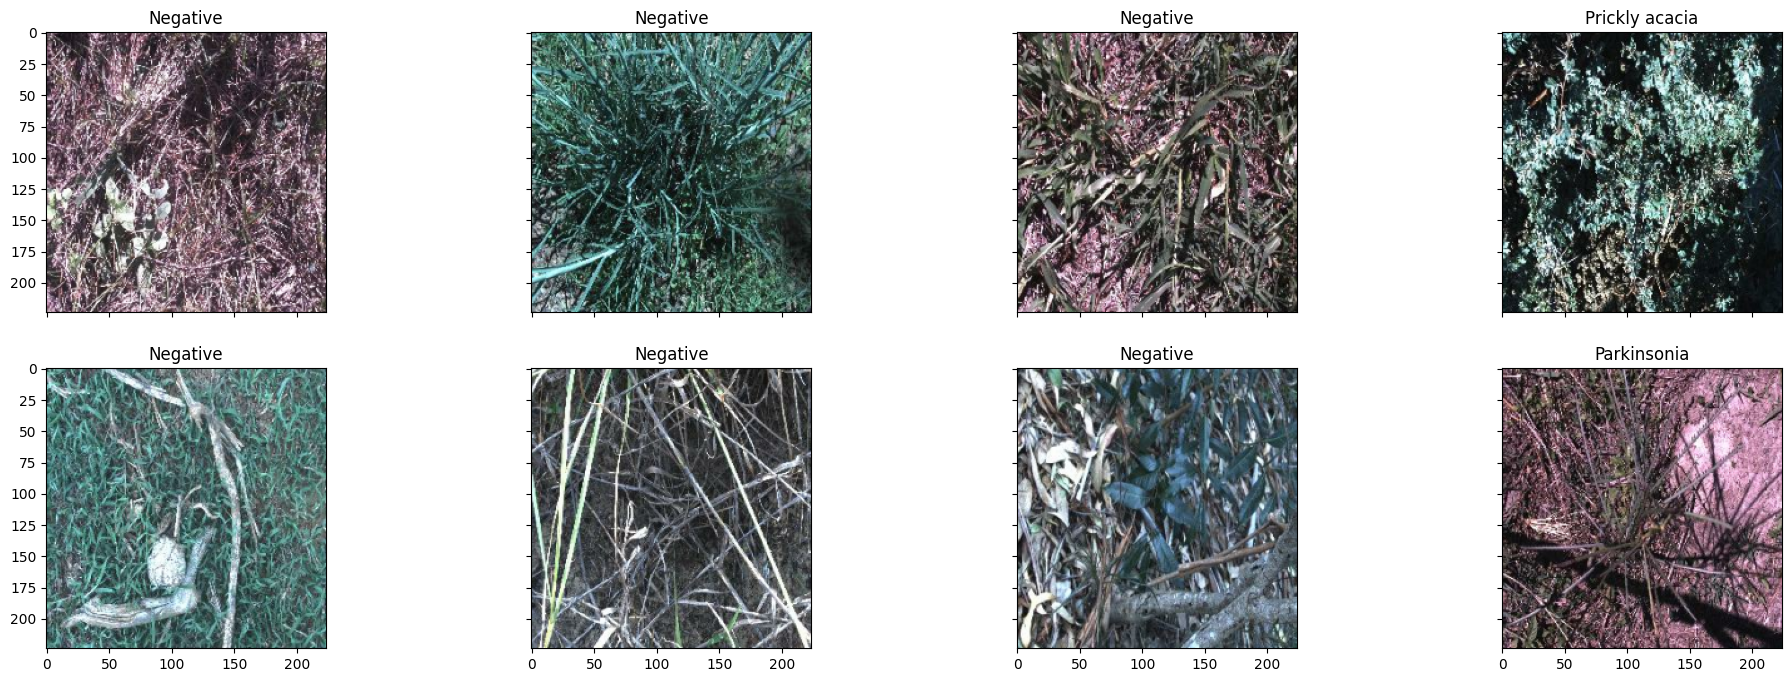

In [14]:
#image visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 4, sharex=True, sharey=True, figsize=(24,8))

for images, labels in validation_generator:
    for i in range(2):
        for j in range(4):
            ax[i][j].imshow(images[i+j*2].numpy().astype(np.int32))
            ax[i][j].set_title(id2label[np.argmax(labels[i+j*2])])

    break
plt.show()

In [15]:
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.layers as layers
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, MaxPool2D, Reshape, \
                        Dense, multiply, Permute, Concatenate, Conv2D, Add, Activation, Lambda, Average
from tensorflow.keras import backend as K
from tensorflow.keras.activations import sigmoid, softmax

class ChannelWiseMaxPool(tf.keras.layers.Layer):
    def __init__(self,pool_size=2,stride=None,padding='valid',data_format='channels_last', **kwargs):
        super(ChannelWiseMaxPool,self).__init__(**kwargs)
        self.pool_size = pool_size
        self.stride = stride
        self.padding = padding
        if stride is None:
            self.stride = self.pool_size

        self.data_format = 'channels_last' if data_format == 'channels_first' else 'channels_first'
        self.max = tf.keras.layers.MaxPool1D(self.pool_size, self.stride, padding=self.padding, data_format=self.data_format)

    def build(self,input_shape):
        self.reshape_forward = tf.keras.layers.Reshape((-1,input_shape[-1]))
        self.reshape_backward= tf.keras.layers.Reshape((input_shape[1], input_shape[2], -1))

    def call(self,x):
        x = self.reshape_forward(x)
        x = self.max(x)
        x = self.reshape_backward(x)
        return x


class ChannelWiseAvgPool(tf.keras.layers.Layer):
    def __init__(self,pool_size=2,stride=None,padding='valid',data_format='channels_last', **kwargs):
        super(ChannelWiseAvgPool,self).__init__(**kwargs)
        self.pool_size = pool_size
        self.stride = stride
        self.padding = padding
        if stride is None:
            self.stride = self.pool_size

        ## data_format parameter is of 2D Image, hence for 1D pool across channel have to reverse the data_format.
        self.data_format = 'channels_last' if data_format == 'channels_first' else 'channels_first'
        self.avg = tf.keras.layers.AveragePooling1D(self.pool_size, self.stride, padding=self.padding, data_format=self.data_format)

    def build(self,input_shape):
        self.reshape_forward = tf.keras.layers.Reshape((-1,input_shape[-1]))
        self.reshape_backward= tf.keras.layers.Reshape((input_shape[1], input_shape[2], -1))

    def call(self,x):
        x = self.reshape_forward(x)
        x = self.avg(x)
        x = self.reshape_backward(x)
        return x

class ChannelWiseConvolution(tf.keras.layers.Layer):
    def __init__(self, channel_conv_filters, channel_conv_kernel_size=16, channel_conv_strides=8, channel_conv_padding='same', channel_conv_activation=None, data_format='channels_last', **kwargs):
        super(ChannelWiseConvolution,self).__init__(**kwargs)
        
        ## data_format parameter is of 2D Image, hence for 1D pool across channel have to reverse the data_format.
        self.data_format = 'channels_last' if data_format == 'channels_first' else 'channels_first'
        self.channel_conv = tf.keras.layers.Conv1D(filters = channel_conv_filters, kernel_size=channel_conv_kernel_size, strides=channel_conv_strides, padding=channel_conv_padding, activation=channel_conv_activation, use_bias=False, data_format=self.data_format)
      
    def build(self,input_shape):
        self.reshape_forward = tf.keras.layers.Reshape((-1, input_shape[-1]))
        self.reshape_backward= tf.keras.layers.Reshape((input_shape[1], input_shape[2], -1))

    def call(self,x):
        x = self.channel_conv(self.reshape_forward(x))
        x = self.reshape_backward(x)
        return x


def GlobalAverageOfMaximums(x, max_pool_size=2, layer_num=1, keep_out_dims=False):
    _max = layers.MaxPooling2D(pool_size=max_pool_size,padding='same', name="Maximums_L{}".format(layer_num))(x)
    _avg = layers.GlobalAveragePooling2D(name="Average_of_Maximums_L{}".format(layer_num), keepdims=keep_out_dims)(_max)
    return _avg

In [16]:
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, MaxPool2D, Reshape, \
Dense, multiply, Permute, Concatenate, Conv2D, Add, Activation, Lambda, Average
from tensorflow.keras import backend as K
from tensorflow.keras.activations import sigmoid, softmax

def cbam_block(cbam_feature, ratio=8):
    """Contains the implementation of Convolutional Block Attention Module(CBAM) block.
    As described in https://arxiv.org/abs/1807.06521.
    """

    cbam_feature = channel_attention(cbam_feature, ratio)
    cbam_feature = spatial_attention(cbam_feature)
    return cbam_feature

def channel_attention(input_feature, ratio=8, seed=42, layer_num=0):
    channel_axis = 1 if K.image_data_format() == "channels_first" else -1
    channel = input_feature.shape[channel_axis]

    shared_layer_one = Dense(channel//ratio,
                             activation='relu',
                             kernel_initializer=keras.initializers.HeUniform(seed),
                             use_bias=True,
                             bias_initializer=keras.initializers.GlorotUniform(seed),
                           name=f'Dense_Squeeze_CA_{layer_num}')
    shared_layer_two = Dense(channel,
                             kernel_initializer=keras.initializers.HeUniform(seed),
                             use_bias=True,
                             bias_initializer=keras.initializers.GlorotUniform(seed),
                           name=f'Dense_Excite_CA_{layer_num}')

    avg_pool = GlobalAveragePooling2D(keepdims=True)(input_feature)
    assert avg_pool.shape[1:] == (1,1,channel)

    avg_pool = shared_layer_one(avg_pool)
    assert avg_pool.shape[1:] == (1,1,channel//ratio)

    avg_pool = shared_layer_two(avg_pool)
    assert avg_pool.shape[1:] == (1,1,channel)

    max_pool = GlobalMaxPooling2D(keepdims=True)(input_feature)
    assert max_pool.shape[1:] == (1,1,channel)

    max_pool = shared_layer_one(max_pool)
    assert max_pool.shape[1:] == (1,1,channel//ratio)

    max_pool = shared_layer_two(max_pool)
    assert max_pool.shape[1:] == (1,1,channel)

    cbam_feature = Add()([avg_pool,max_pool])
    cbam_feature = Activation('sigmoid')(cbam_feature)

    if K.image_data_format() == "channels_first":
        cbam_feature = Permute((3, 1, 2))(cbam_feature)

    return multiply([input_feature, cbam_feature])



def spatial_attention(input_feature, seed=42):
    kernel_size = 5

    if K.image_data_format() == "channels_first":
        channel = input_feature.shape[1]
        cbam_feature = Permute((2,3,1))(input_feature)
    else:
        channel = input_feature.shape[-1]
        cbam_feature = input_feature

    avg_pool = Lambda(lambda x: K.mean(x, axis=3, keepdims=True))(cbam_feature)
    assert avg_pool.shape[-1] == 1

    max_pool = Lambda(lambda x: K.max(x, axis=3, keepdims=True))(cbam_feature)
    assert max_pool.shape[-1] == 1

    concat = Concatenate(axis=3)([avg_pool, max_pool])
    assert concat.shape[-1] == 2

    cbam_feature = Conv2D(filters = 1,
                    kernel_size=kernel_size,
                    strides=1,
                    padding='same',
                    activation='sigmoid',
                    kernel_initializer=keras.initializers.HeUniform(seed),
                    use_bias=False)(concat)
    assert cbam_feature.shape[-1] == 1

    if K.image_data_format() == "channels_first":
        cbam_feature = Permute((3, 1, 2))(cbam_feature)

    return multiply([input_feature, cbam_feature])

In [17]:
import math
### MFSA
def MultiFilterSpatialAttention(input_feature, kernel_size=7, num_pooled_channel=4, seed=42, layer_num = 0):
    in_shape = input_feature.shape

    stride = in_shape[-1] // num_pooled_channel
    pool_size = (stride * 2)

    channel_avg = ChannelWiseAvgPool(pool_size, stride, padding='same', name='MFSA_CWAP_L{}'.format(layer_num))(input_feature)
    channel_max = ChannelWiseMaxPool(pool_size, stride, padding='same' , name='MFSA_CWMP_L{}'.format(layer_num))(input_feature)
    
    concat = Concatenate(axis=3)([channel_avg, channel_max])
    mixed = layers.Conv2D(num_pooled_channel, 1, 1, use_bias=False, activation='relu', kernel_initializer=keras.initializers.HeUniform(seed), name="MFSA_ConvMix_L{}".format(layer_num))(concat)
    
    mfsa = layers.Conv2D(filters = in_shape[-1],
                    kernel_size=kernel_size,
                    strides=1,
                    padding='same',
                    activation='relu',
                    kernel_initializer=keras.initializers.HeUniform(seed),
                    use_bias=False,
                    groups=num_pooled_channel,
                    name="MFSA_ConvAttn_L{}".format(layer_num))

    mfsa_feature = mfsa(mixed)    
    attn_score = layers.Activation('sigmoid')(mfsa_feature)
    
    return layers.Multiply(name="MFSA_Multiply_L{}".format(layer_num))([input_feature, attn_score])


def modified_cbam_block(cbam_feature, ratio=8, mfsa_kernel=7, seed=42, order='normal', layer_num=0):
    """Contains the implementation of Convolutional Block Attention Module(CBAM) block.
    As described in https://arxiv.org/abs/1807.06521.
    """
    mfsa_pool_size = cbam_feature.shape[-1] // ratio
    if order == 'inverted':
        cbam_feature = MultiFilterSpatialAttention(cbam_feature, kernel_size=mfsa_kernel, num_pooled_channel=mfsa_pool_size, seed=seed, layer_num=layer_num)
        cbam_feature = channel_attention(cbam_feature, ratio, layer_num=layer_num, seed=seed)
    else:
        cbam_feature = channel_attention(cbam_feature, ratio, layer_num=layer_num, seed=seed)
        cbam_feature = MultiFilterSpatialAttention(cbam_feature, kernel_size=mfsa_kernel, num_pooled_channel=mfsa_pool_size, seed=seed, layer_num=layer_num)
        
    return cbam_feature

# Building MobileNet Model

In [24]:
from tensorflow.keras.applications import MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large
from tensorflow.keras.applications import EfficientNetV2S, ConvNeXtSmall

def augment(seed=42):
    return keras.Sequential([
        layers.RandomBrightness(0.3, (0, 1),seed=seed, name='RR_Bright'),
        # layers.RandomContrast(0.3, seed=seed, name='RR_Contr'), # can't run deterministically
        layers.RandomFlip(seed=seed, name='RR_Flip'),
        layers.RandomRotation(0.5, seed=seed, name='RR_Rot'),
        layers.RandomTranslation(0.4, 0.4, seed=seed, name='RR_Trans'),
        layers.RandomZoom(0.2, 0.2, seed=seed, name='RR_Zoom'),
        layers.GaussianDropout(0.01, seed=seed, name='RR_Gauss'),
    ], name='augment_pipeline')


def skipAugment(model):
    inputs = keras.Input(shape=IMG_SIZE)
    x = inputs
    for layer in model.layers:
        if 'augment' not in layer.name and 'input' not in layer.name:
            x = layer(x)

    model = keras.Model(inputs=inputs, outputs=x, name=model.name)
    return model


def hard_sigmoid(x):
    relu6 = layers.ReLU(max_value=6)
    return relu6(x + 3) / 6
    
def hard_swish(x):
    return x * hard_sigmoid(x)

def MobilenetV3Base(img_size, use='S'): # use = S (small) or L (large)
    # Load the MobileNet model with weights pre-trained on ImageNet.
    if(use=='S'):
        mobilenet = MobileNetV3Small(input_shape=img_size, weights='imagenet', include_preprocessing=False)
    if(use=='L'):
        mobilenet = MobileNetV3Large(input_shape=img_size, weights='imagenet', include_preprocessing=False)
        
    mobilenet.trainable = True

    base_index = 0
    for i in range(len(mobilenet.layers)):
        if('global_average_pooling2d' in mobilenet.layers[i].name):
            base_index = i
            break
            
    out_layer = mobilenet.layers[base_index-1]
    base_model =  keras.Model(inputs=mobilenet.layers[0].output, outputs=out_layer.output, name = mobilenet.name+"_base_")
    base_model.trainable = True
    
    pi0 = base_index+1 # pooler index start
    pi1 = base_index+1 # pooler index end
    for i in range(base_index, len(mobilenet.layers)):
        if('dropout' in mobilenet.layers[i].name):
            pi1 = i
            break
    
    pooler = keras.Model(inputs=mobilenet.layers[pi0].input, outputs=mobilenet.layers[pi1].output, name="MobileNet-Pooler")
    
    return base_model , pooler

def buildModel(IMG_SIZE, mtype = 'S', fusion_type='average', cbam_order='normal', skip_preprocess=False):
    # Load the MobileNet model with weights pre-trained on ImageNet.
    base_model, pooler = MobilenetV3Base(IMG_SIZE, use=mtype)
    base_model.trainable = True
    pooler.trainable = True
    # out_dim = 1024 if "small" in base_model.name.lower() else 1280 if "large" in base_model.name.lower() else base_model.output.shape[-1]

    print("Base Model:", base_model.name)
    print(len(base_model.layers))
    
    # Define the input layer.
    inputs = keras.Input(shape=IMG_SIZE, name='input')

    # Pre-process the input.
    if not skip_preprocess:
        x = layers.Rescaling(1./255, name='PP_Rescale_down')(inputs)
        x = layers.Resizing(IMG_SIZE[0], IMG_SIZE[1], name='PP_Resize')(x)
    
        x = augment(seed)(x)
    else:
        x = inputs
    
    x = base_model(x, training=True)
    x = layers.Dropout(0.3, seed=seed)(x) 
    
    ### Global Average of Maximums
    gavm_x = GlobalAverageOfMaximums(x, keep_out_dims=True, layer_num="_pre")

    x = modified_cbam_block(x, ratio=8, mfsa_kernel=7, order=cbam_order, seed=seed, layer_num=0)
    x = GlobalAverageOfMaximums(x, keep_out_dims=True, layer_num="_post")
    
    if fusion_type == 'average':
        x = layers.Average()([gavm_x, x])
    elif fusion_type == 'add':
        x = layers.Add()([gavm_x, x])
    else: 
        x = layers.Average()([gavm_x, x])
        
    x = layers.Dropout(0.3)(x)
    x = pooler(x)
    x = layers.Reshape((8, -1))(x)
    x = layers.Dense(128, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed))(x)
    x = layers.Dense(256, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed))(x)
    x = layers.Dense(128, activation='relu', use_bias=False, kernel_regularizer='l1_l2')(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(9, kernel_initializer=keras.initializers.HeUniform(seed), activation='softmax')(x)
    model_name = "DeepWeeds-" + base_model.name
    
    # Create the model.
    model = keras.Model(inputs=inputs, outputs=outputs, name=model_name)
    return model

In [25]:
model = buildModel(IMG_SIZE, mtype=MODEL_TYPE, fusion_type=FUSION_TYPE, cbam_order=CBAM_ORDER)
model.summary()

Base Model: MobilenetV3small_base_
228
Model: "DeepWeeds-MobilenetV3small_base_"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 PP_Rescale_down (Rescaling  (None, 224, 224, 3)          0         ['input[0][0]']               
 )                                                                                                
                                                                                                  
 PP_Resize (Resizing)        (None, 224, 224, 3)          0         ['PP_Rescale_down[0][0]']     
                                                                                                  
 augment_pipeline (Sequenti 

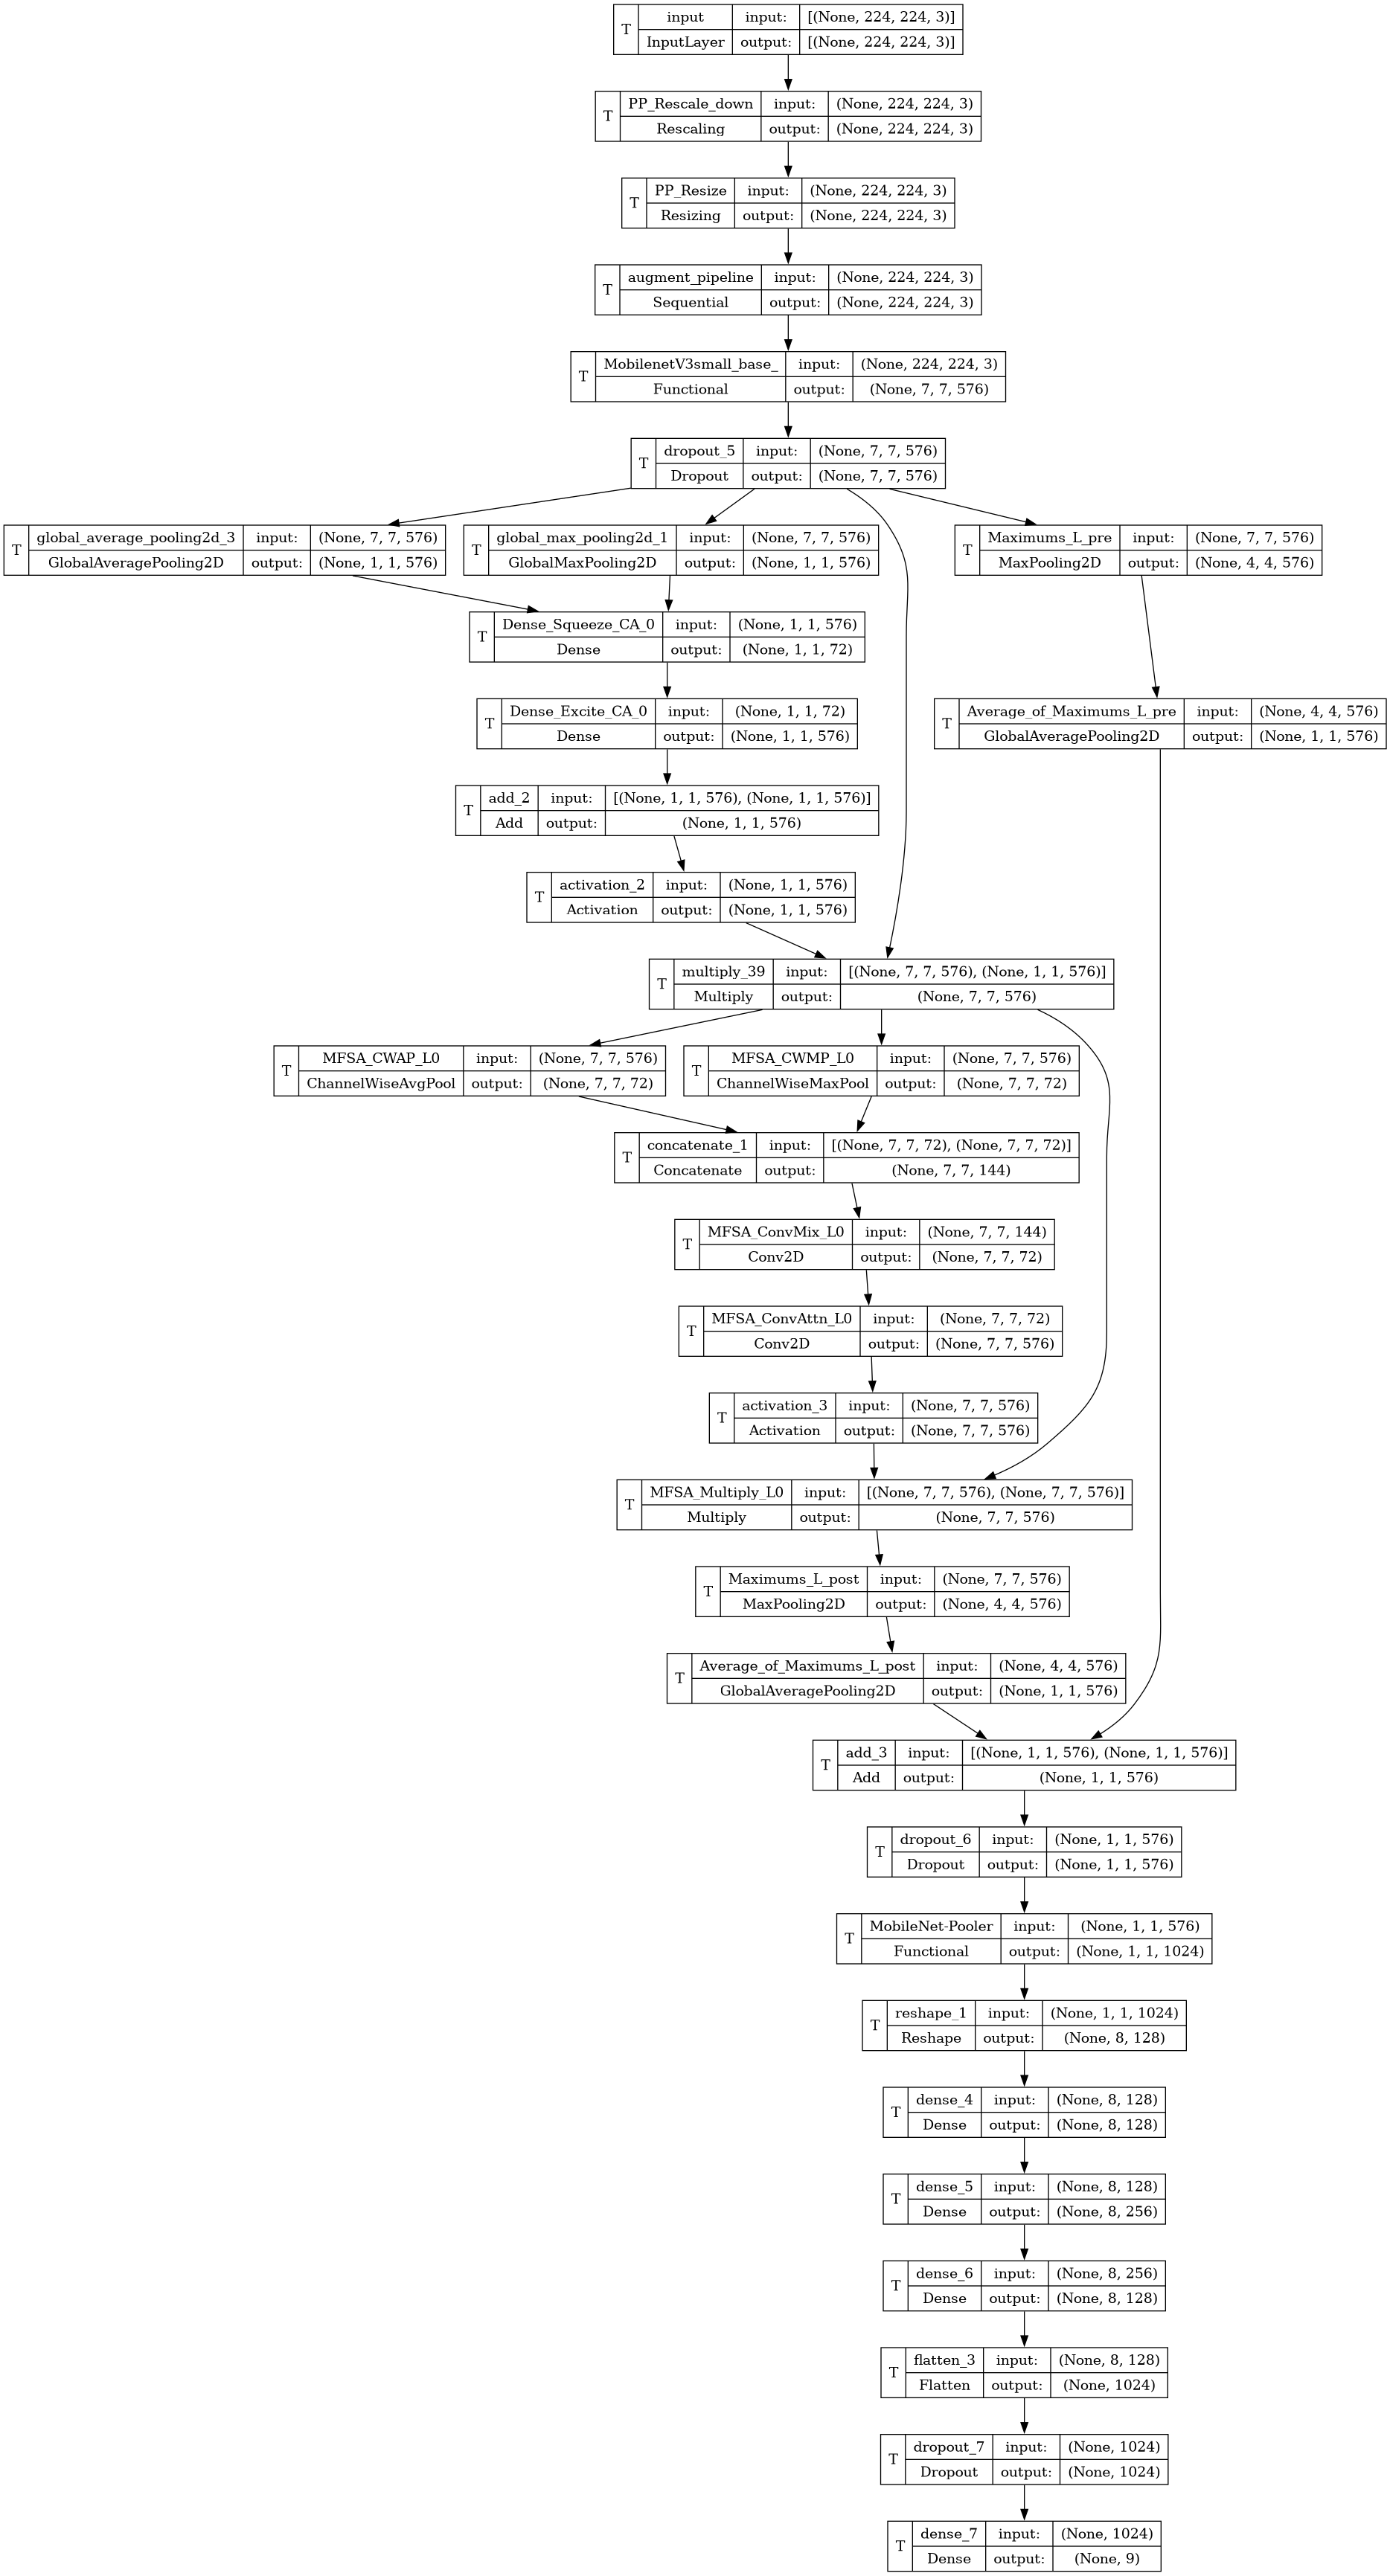

In [26]:
tf.keras.utils.plot_model(model, show_trainable=True, show_layer_names=True, show_shapes=True)

# Trial 1 - FineTuning

In [27]:
from tensorflow.keras.optimizers import Adam, AdamW

early_stopping = tf.keras.callbacks.EarlyStopping(monitor=ES_MONITOR, patience=ES_PATIENCE, verbose=1, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor=LR_REDUCTION_MONITOR,factor=LR_REDUCTION_FACTOR, patience=LR_REDUCTION_PATIENCE, verbose=1, min_lr=MIN_LR1)

def scheduler(e, lr):
    if e < WARMUP_EPOCH:
        t = lr + (lr * WARMUP_INCREMENT_RATE)
        return t if t < WARMUP_MAX_LR else WARMUP_MAX_LR
    else:
        return lr
    
warmup = keras.callbacks.LearningRateScheduler(scheduler)
callbacks = [early_stopping, reduce_lr] + ([warmup] if USE_WARMUP else [])

model.compile(loss='categorical_crossentropy',
          optimizer=AdamW(learning_rate=WARMUP_INIT_LR if USE_WARMUP else INIT_LR1,  weight_decay=W_DECAY1),
          metrics=['accuracy'])

model.optimizer.get_config()

{'name': 'AdamW',
 'weight_decay': 0.05,
 'clipnorm': None,
 'global_clipnorm': None,
 'clipvalue': None,
 'use_ema': False,
 'ema_momentum': 0.99,
 'ema_overwrite_frequency': None,
 'jit_compile': True,
 'is_legacy_optimizer': False,
 'learning_rate': 0.0002,
 'beta_1': 0.9,
 'beta_2': 0.999,
 'epsilon': 1e-07,
 'amsgrad': False}

Epoch 1/300


2025-06-14 13:27:12.769706: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDeepWeeds-MobilenetV3small_base_/dropout_5/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


329/329 [==============================] - 48s 80ms/step - loss: 19.8575 - accuracy: 0.4382 - val_loss: 14.8940 - val_accuracy: 0.5447 - lr: 2.0000e-04
Epoch 2/300
329/329 [==============================] - 25s 75ms/step - loss: 10.7956 - accuracy: 0.5269 - val_loss: 7.2732 - val_accuracy: 0.6107 - lr: 2.0000e-04
Epoch 3/300
329/329 [==============================] - 25s 75ms/step - loss: 5.0759 - accuracy: 0.5669 - val_loss: 3.3313 - val_accuracy: 0.6552 - lr: 2.0000e-04
Epoch 4/300
329/329 [==============================] - 25s 74ms/step - loss: 2.5107 - accuracy: 0.6102 - val_loss: 1.8124 - val_accuracy: 0.6947 - lr: 2.0000e-04
Epoch 5/300
329/329 [==============================] - 25s 74ms/step - loss: 1.6170 - accuracy: 0.6428 - val_loss: 1.2855 - val_accuracy: 0.7149 - lr: 2.0000e-04
Epoch 6/300
329/329 [==============================] - 25s 75ms/step - loss: 1.2733 - accuracy: 0.6771 - val_loss: 1.0375 - val_accuracy: 0.7535 - lr: 2.0000e-04
Epoch 7/300
329/329 [================

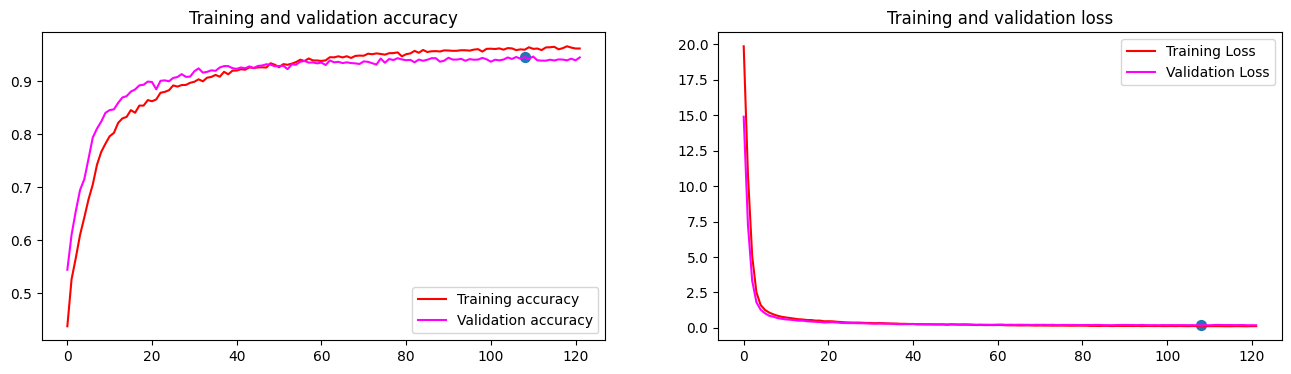

CPU times: user 1h 31min 39s, sys: 5min 8s, total: 1h 36min 48s
Wall time: 50min 41s


In [28]:
%%time

# Train the model
history1 = model.fit(
      train_generator,
      epochs=EPOCHS,
      validation_data=validation_generator,
      callbacks=[early_stopping, reduce_lr, warmup],
    )

print("Saving the Model")
model.save(MODEL_NAME)

# Plot training results
plot_loss_acc(history1.history)

# Evaluation#1

Train Set Statistics
model.evaluate
329/329 [==============================] - 8s 24ms/step - loss: 0.0670 - accuracy: 0.9823
model.predict


  0%|          | 0/329 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.94698   0.95259   0.94978       675
       Lantana    0.99512   0.96075   0.97764       637
   Parkinsonia    0.97464   0.99515   0.98479       618
    Parthenium    0.98852   0.98369   0.98610       613
Prickly acacia    0.98089   0.96703   0.97391       637
   Rubber vine    0.98847   0.99174   0.99010       605
     Siam weed    0.99218   0.98447   0.98831       644
    Snake weed    0.95588   0.96059   0.95823       609
      Negative    0.98686   0.98993   0.98839      5463

      accuracy                        0.98238     10501
     macro avg    0.97884   0.97622   0.97747     10501
  weighted avg    0.98244   0.98238   0.98238     10501


                False Positive Rate  Accuracy
Chinee apple               0.003664  0.952593
Lantana                    0.000304  0.960754
Parkinsonia                0.001619  0.995146
Parthenium                 0.000708  0.983687
Prickly acacia    

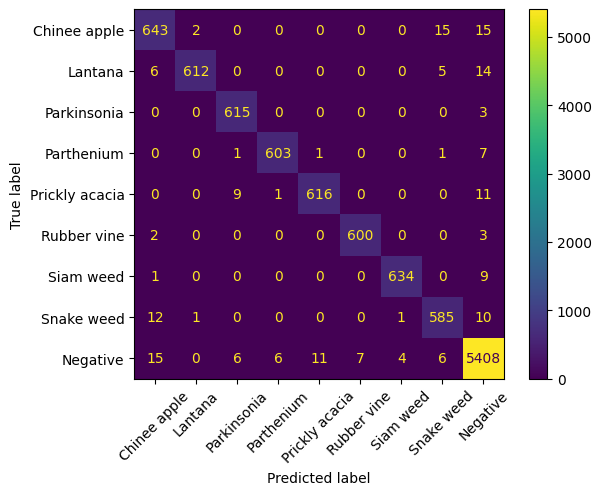


Validation Set Statistics
model.evaluate
110/110 [==============================] - 3s 24ms/step - loss: 0.1929 - accuracy: 0.9429
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.84120   0.87111   0.85590       225
       Lantana    0.95431   0.88263   0.91707       213
   Parkinsonia    0.94258   0.95631   0.94940       206
    Parthenium    0.94444   0.91667   0.93035       204
Prickly acacia    0.94660   0.91981   0.93301       212
   Rubber vine    0.95960   0.94059   0.95000       202
     Siam weed    0.96078   0.91163   0.93556       215
    Snake weed    0.85000   0.83744   0.84367       203
      Negative    0.94881   0.96705   0.95785      1821

      accuracy                        0.93688      3501
     macro avg    0.92759   0.91147   0.91920      3501
  weighted avg    0.93711   0.93688   0.93677      3501


                False Positive Rate  Accuracy
Chinee apple               0.011294  0.871111
Lantana                    0.002737  0.882629
Parkinsonia                0.003642  0.956311
Parthenium                 0.003336  0.916667
Prickly acacia    

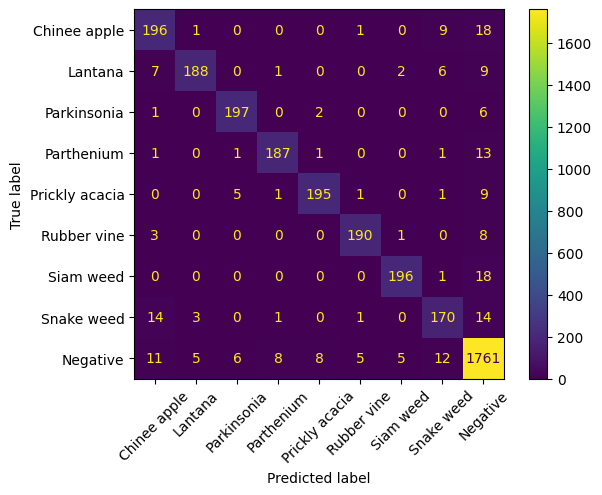


Testn Set Statistics
model.evaluate
110/110 [==============================] - 3s 26ms/step - loss: 3.6435 - accuracy: 0.4619
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.10471   0.08850   0.09592       226
       Lantana    0.11236   0.04695   0.06623       213
   Parkinsonia    0.29630   0.07729   0.12261       207
    Parthenium    0.12329   0.04390   0.06475       205
Prickly acacia    0.16667   0.03286   0.05490       213
   Rubber vine    0.15584   0.05941   0.08602       202
     Siam weed    0.18841   0.06047   0.09155       215
    Snake weed    0.17284   0.06863   0.09825       204
      Negative    0.53656   0.83370   0.65291      1822

      accuracy                        0.46193      3507
     macro avg    0.20633   0.14574   0.14813      3507
  weighted avg    0.35773   0.46193   0.38005      3507


                False Positive Rate  Accuracy
Chinee apple               0.052118  0.088496
Lantana                    0.023983  0.046948
Parkinsonia                0.011515  0.077295
Parthenium                 0.019382  0.043902
Prickly acacia    

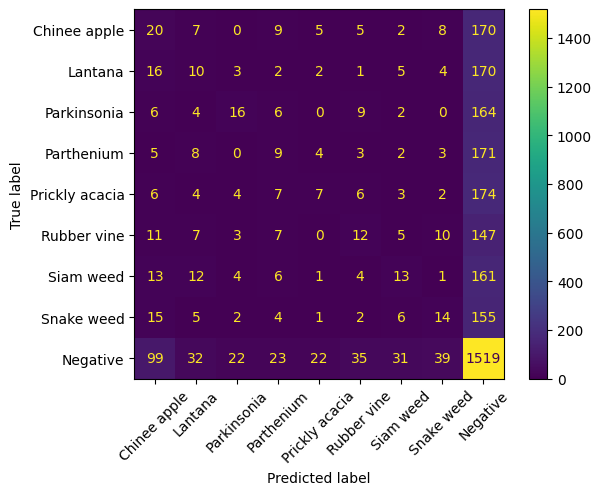

In [29]:
with tf.device(DEVICE):
    print("Train Set Statistics")
    a, b = eval_model(model, train_generator)
    
    print("\nValidation Set Statistics")
    a, b = eval_model(model, validation_generator)
    
    print("\nTestn Set Statistics")
    a, b = eval_model(model, test_generator)

# Trial 2 - Freezing Base Model

In [30]:
for layer in model.layers:
    if 'base' in layer.name.lower():
        print("Freezing Layer", layer.name)
        layer.trainable = False

model.compile(loss='categorical_crossentropy',
          optimizer=AdamW(learning_rate=INIT_LR2,  weight_decay=W_DECAY2),
          metrics=['accuracy'])

model.optimizer.get_config()

Freezing Layer MobilenetV3small_base_


{'name': 'AdamW',
 'weight_decay': 5e-05,
 'clipnorm': None,
 'global_clipnorm': None,
 'clipvalue': None,
 'use_ema': False,
 'ema_momentum': 0.99,
 'ema_overwrite_frequency': None,
 'jit_compile': True,
 'is_legacy_optimizer': False,
 'learning_rate': 2e-05,
 'beta_1': 0.9,
 'beta_2': 0.999,
 'epsilon': 1e-07,
 'amsgrad': False}

## Test after Freezing ##

Validation Set Statistics
model.evaluate
110/110 [==============================] - 5s 25ms/step - loss: 0.1611 - accuracy: 0.9534
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.88393   0.88000   0.88196       225
       Lantana    0.96465   0.89671   0.92944       213
   Parkinsonia    0.95652   0.96117   0.95884       206
    Parthenium    0.93750   0.95588   0.94660       204
Prickly acacia    0.95215   0.93868   0.94537       212
   Rubber vine    0.96954   0.94554   0.95739       202
     Siam weed    0.96172   0.93488   0.94811       215
    Snake weed    0.89268   0.90148   0.89706       203
      Negative    0.96638   0.97858   0.97244      1821

      accuracy                        0.95344      3501
     macro avg    0.94279   0.93255   0.93747      3501
  weighted avg    0.95347   0.95344   0.95333      3501


                False Positive Rate  Accuracy
Chinee apple               0.007937  0.880000
Lantana                    0.002129  0.896714
Parkinsonia                0.002731  0.961165
Parthenium                 0.003943  0.955882
Prickly acacia    

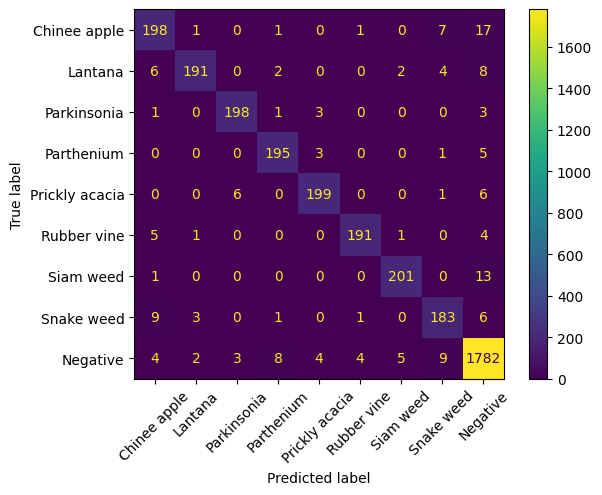

Test Set Statistics
model.evaluate
110/110 [==============================] - 3s 24ms/step - loss: 0.1526 - accuracy: 0.9538
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.91818   0.89381   0.90583       226
       Lantana    0.96040   0.91080   0.93494       213
   Parkinsonia    0.95370   0.99517   0.97400       207
    Parthenium    0.94686   0.95610   0.95146       205
Prickly acacia    0.92823   0.91080   0.91943       213
   Rubber vine    0.95939   0.93564   0.94737       202
     Siam weed    0.95305   0.94419   0.94860       215
    Snake weed    0.91133   0.90686   0.90909       204
      Negative    0.96522   0.97475   0.96996      1822

      accuracy                        0.95381      3507
     macro avg    0.94404   0.93646   0.94007      3507
  weighted avg    0.95368   0.95381   0.95364      3507


                False Positive Rate  Accuracy
Chinee apple               0.005486  0.893805
Lantana                    0.002429  0.910798
Parkinsonia                0.003030  0.995169
Parthenium                 0.003331  0.956098
Prickly acacia    

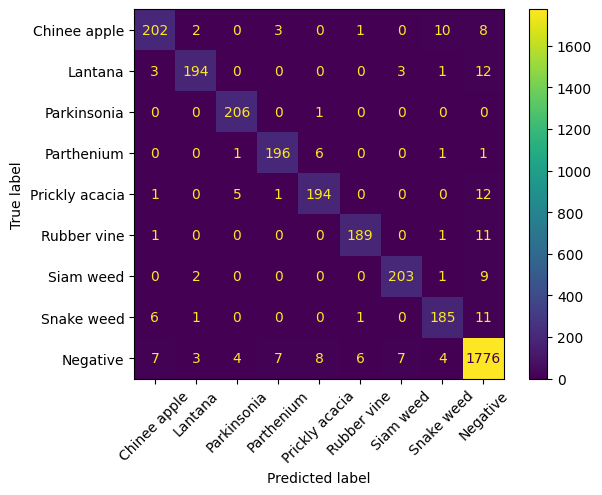

In [31]:
print("## Test after Freezing ##")
with tf.device(DEVICE):
    print("\nValidation Set Statistics")
    a, b = eval_model(model, validation_generator)

    print("Test Set Statistics")
    a, b = eval_model(model, test_generator)

Epoch 1/300


2025-06-14 14:20:31.273199: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDeepWeeds-MobilenetV3small_base_/dropout_5/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


329/329 [==============================] - 19s 40ms/step - loss: 0.2145 - accuracy: 0.9298 - val_loss: 0.1781 - val_accuracy: 0.9497 - lr: 2.0000e-05
Epoch 2/300
329/329 [==============================] - 13s 40ms/step - loss: 0.1972 - accuracy: 0.9373 - val_loss: 0.1882 - val_accuracy: 0.9480 - lr: 2.0000e-05
Epoch 3/300
329/329 [==============================] - 14s 41ms/step - loss: 0.2068 - accuracy: 0.9364 - val_loss: 0.1919 - val_accuracy: 0.9469 - lr: 2.0000e-05
Epoch 4/300
327/329 [============================>.] - ETA: 0s - loss: 0.1866 - accuracy: 0.9420
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.5999999595806004e-05.
329/329 [==============================] - 14s 41ms/step - loss: 0.1871 - accuracy: 0.9418 - val_loss: 0.1908 - val_accuracy: 0.9466 - lr: 2.0000e-05
Epoch 5/300
329/329 [==============================] - 13s 40ms/step - loss: 0.1944 - accuracy: 0.9388 - val_loss: 0.1903 - val_accuracy: 0.9463 - lr: 1.6000e-05
Epoch 6/300
329/329 [===================

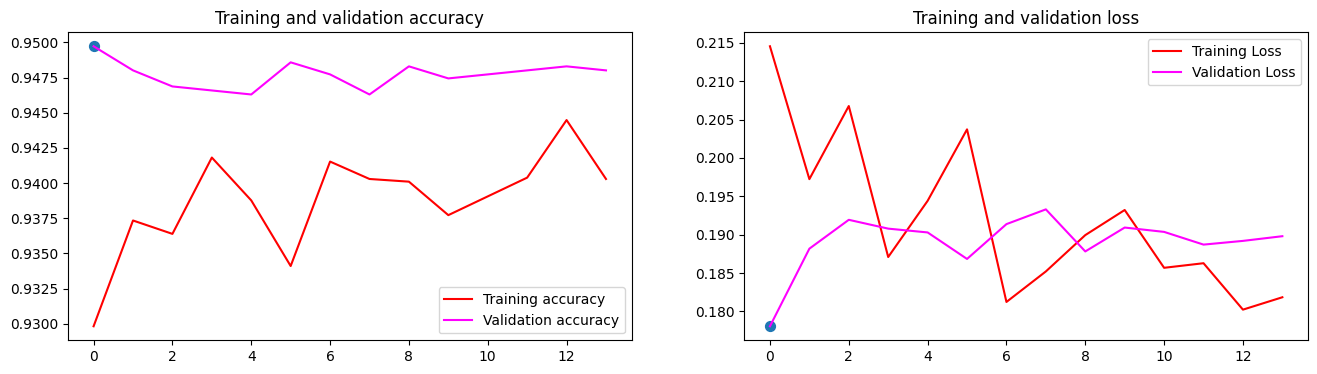

In [32]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor=LR_REDUCTION_MONITOR,factor=LR_REDUCTION_FACTOR, patience=LR_REDUCTION_PATIENCE, verbose=LR_REDUCTION_PATIENCE, min_lr=MIN_LR2)

# Train the model
history2 = model.fit(
      train_generator,
      epochs=EPOCHS,
      validation_data=validation_generator,
      callbacks=[early_stopping,reduce_lr]
    )

print("Saving the Model")
model.save(MODEL_NAME)

# Plot training results
plot_loss_acc(history2.history)

# Accuracy / Loss Plots

Total Epochs: range(0, 136)


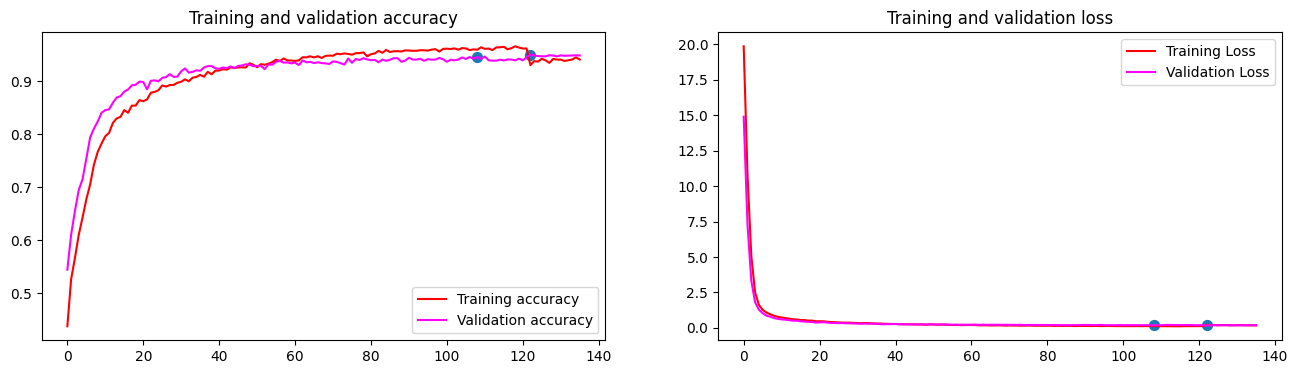

In [33]:
import copy

history = copy.deepcopy(history1.history)

for key in history:
    history[key].extend(history2.history[key])


h1len = len(history1.history['accuracy'])
h2len = len(history2.history['accuracy'])

pat_es = ES_PATIENCE + 1
history['peaks'] = [h1len-pat_es, (h1len+h2len)-pat_es]
history['peaks'] = [i if i>=0 else 0 for i in history['peaks']]

plot_loss_acc(history)

Total Epochs: range(0, 122)


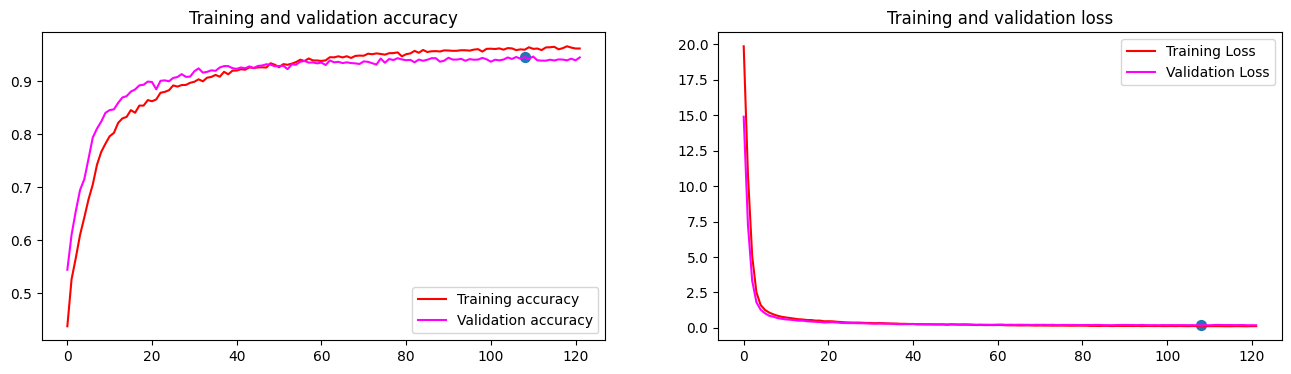

Total Epochs: range(0, 14)


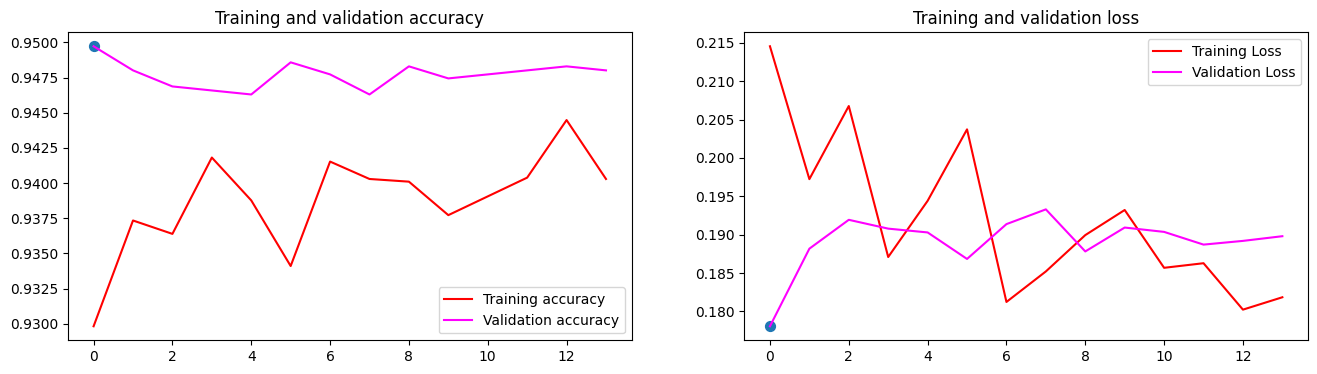

In [34]:
plot_loss_acc(history1.history)
plot_loss_acc(history2.history)

# Evaluation#2

Train Set Statistics
model.evaluate
329/329 [==============================] - 8s 24ms/step - loss: 0.0462 - accuracy: 0.9902
model.predict


  0%|          | 0/329 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.98085   0.98667   0.98375       675
       Lantana    1.00000   0.97959   0.98969       637
   Parkinsonia    0.99196   0.99838   0.99516       618
    Parthenium    0.99673   0.99511   0.99592       613
Prickly acacia    0.97377   0.99058   0.98210       637
   Rubber vine    0.98693   0.99835   0.99260       605
     Siam weed    0.95549   1.00000   0.97724       644
    Snake weed    0.97581   0.99343   0.98454       609
      Negative    0.99760   0.98792   0.99273      5463

      accuracy                        0.99019     10501
     macro avg    0.98435   0.99222   0.98819     10501
  weighted avg    0.99038   0.99019   0.99022     10501


                False Positive Rate  Accuracy
Chinee apple               0.001323  0.986667
Lantana                    0.000000  0.979592
Parkinsonia                0.000506  0.998382
Parthenium                 0.000202  0.995106
Prickly acacia    

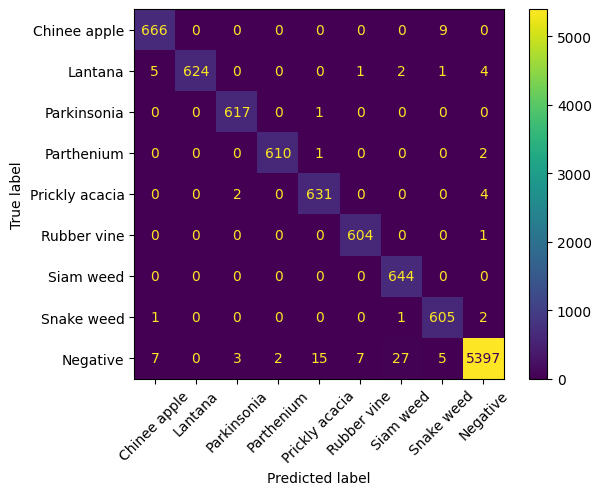


Validation Set Statistics
model.evaluate
110/110 [==============================] - 3s 24ms/step - loss: 0.1781 - accuracy: 0.9497
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.90233   0.86222   0.88182       225
       Lantana    0.96907   0.88263   0.92383       213
   Parkinsonia    0.96117   0.96117   0.96117       206
    Parthenium    0.95522   0.94118   0.94815       204
Prickly acacia    0.94366   0.94811   0.94588       212
   Rubber vine    0.96500   0.95545   0.96020       202
     Siam weed    0.87500   0.97674   0.92308       215
    Snake weed    0.85455   0.92611   0.88889       203
      Negative    0.97185   0.96705   0.96945      1821

      accuracy                        0.94973      3501
     macro avg    0.93309   0.93563   0.93361      3501
  weighted avg    0.95077   0.94973   0.94983      3501


                False Positive Rate  Accuracy
Chinee apple               0.006410  0.862222
Lantana                    0.001825  0.882629
Parkinsonia                0.002428  0.961165
Parthenium                 0.002730  0.941176
Prickly acacia    

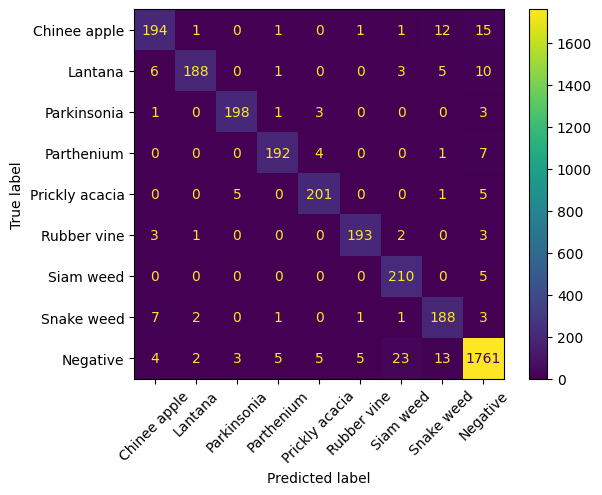


Testn Set Statistics
model.evaluate
110/110 [==============================] - 3s 24ms/step - loss: 0.1700 - accuracy: 0.9507
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.92488   0.87168   0.89749       226
       Lantana    0.96410   0.88263   0.92157       213
   Parkinsonia    0.96262   0.99517   0.97862       207
    Parthenium    0.95588   0.95122   0.95355       205
Prickly acacia    0.92488   0.92488   0.92488       213
   Rubber vine    0.95477   0.94059   0.94763       202
     Siam weed    0.87552   0.98140   0.92544       215
    Snake weed    0.88679   0.92157   0.90385       204
      Negative    0.97026   0.96707   0.96866      1822

      accuracy                        0.95067      3507
     macro avg    0.93552   0.93736   0.93574      3507
  weighted avg    0.95136   0.95067   0.95063      3507


                False Positive Rate  Accuracy
Chinee apple               0.004877  0.871681
Lantana                    0.002125  0.882629
Parkinsonia                0.002424  0.995169
Parthenium                 0.002726  0.951220
Prickly acacia    

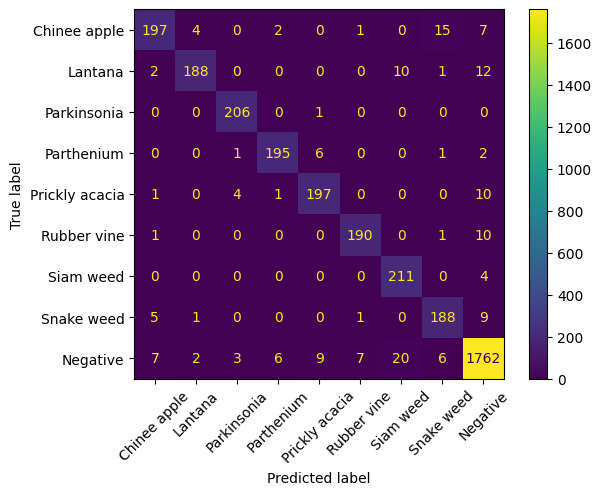

In [35]:
with tf.device(DEVICE):
    print("Train Set Statistics")
    a, b = eval_model(model, train_generator)
    print("\nValidation Set Statistics")
    a, b = eval_model(model, validation_generator)
    print("\nTestn Set Statistics")
    a, b = eval_model(model, test_generator)

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.87225   0.87611   0.87417       226
       Lantana    0.93237   0.90610   0.91905       213
   Parkinsonia    0.96262   0.99517   0.97862       207
    Parthenium    0.95588   0.95122   0.95355       205
Prickly acacia    0.88362   0.96244   0.92135       213
   Rubber vine    0.95477   0.94059   0.94763       202
     Siam weed    0.87552   0.98140   0.92544       215
    Snake weed    0.88679   0.92157   0.90385       204
      Negative    0.98024   0.95280   0.96632      1822

      accuracy                        0.94725      3507
     macro avg    0.92267   0.94304   0.93222      3507
  weighted avg    0.94872   0.94725   0.94754      3507


                False Positive Rate  Accuracy
Chinee apple               0.008839  0.876106
Lantana                    0.004250  0.906103
Parkinsonia                0.002424  0.995169
Parthenium                 0.002726  0.951220
Prickly acacia    

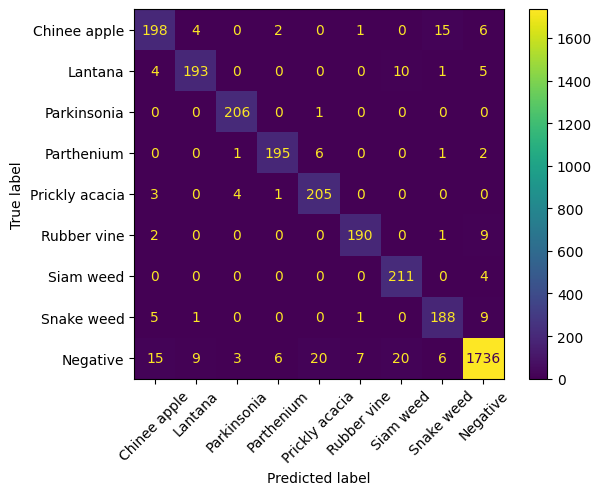

In [36]:
printStats(a,b,0.11)

## Clear Files

In [ ]:
shutil.rmtree(base_dir)

In [ ]:
model = buildModel(IMG_SIZE, mtype=MODEL_TYPE, cbam_order=CBAM_ORDER, skip_preprocess=True)
model.load_weights(MODEL_NAME, skip_mismatch=True)#(model_weights, by_name=True, skip_mismatch=True)
model.trainable= False
model.save(model.name+".keras")
model.summary()